# Создание маски

Импорт библиотек

In [29]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Метод 1: Морфология

Загрузка фото, перевод в HSV, выделение синего и желтого цвета, объеденение масок

In [30]:
# По умолчанию cv2 загружает изображения в формате BGR (синий зелённый красный), а не RGB,
img = cv2.imread("input.jpeg")

# Перевод в цветовое пространство HSV, чтобы не зависитть от освещения и оттенков цвета.
# Hue — тон, Saturation — насыщенность, Value — яркость
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# Выделение желтого цвета
lower_yellow = np.array([15, 40, 40])
upper_yellow = np.array([30, 255, 255])
mask_yellow = cv2.inRange(hsv, lower_yellow, upper_yellow)

# Выделение синего цвета (для надписи внутри объекта)
lower_blue = np.array([90, 40, 40])
upper_blue = np.array([130, 255, 255])
mask_blue = cv2.inRange(hsv, lower_blue, upper_blue)

# Объединение масок
combined_mask = cv2.bitwise_or(mask_yellow, mask_blue)

Создание ядра(матрицы из нулей и едениц ) элиптической формы

0  0  1  0  0
0  1  1  1  0
1  1  1  1  1
0  1  1  1  0
0  0  1  0  0 

In [31]:
kernel_small = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

Проходиться по каждому пикселю изображения

Если ядро наступает своей круглой областью хотя бы на один черный пиксель фона, центральный пиксель стирается в черный цвет. (Эрозия)

Если под круглую область ядра попадает хотя бы один белый пиксель, центральный пиксель заливается белым. (Дилатация)

In [32]:
clean_mask = cv2.morphologyEx(combined_mask, cv2.MORPH_OPEN, kernel_small, iterations=1)

В предыдущем была цель очистить фон снаружи объекта, а ниже уже заделать дыры внутри объекта и сгладить его форму

In [33]:
dilated = cv2.dilate(clean_mask, kernel_small, iterations=4)
mask_morph = cv2.erode(dilated, kernel_small, iterations=4)

Записываю в файл маску

In [34]:
cv2.imwrite("base_mask.png", mask_morph)

True

## Метод 2: GrabCut

Подготовительные данные

In [38]:
mask_gc = np.zeros(img.shape[:2], np.uint8) # Маска для grabCut, 0 - фон, 1 - объект, 2 - вероятный фон, 3 - вероятный объект

bgdModel = np.zeros((1, 65), np.float64) # какие цвета характерны для фона,
fgdModel = np.zeros((1, 65), np.float64) # какие цвета характерны для самого объекта

# Точные координаты в которых находиться объект
rect = (339, 550, 231, 250)

In [ ]:
# cv2.GC_INIT_WITH_RECT - нет ручной разметки кистью, начни алгоритм, отталкиваясь строго от прямоугольника
cv2.grabCut(img, mask_gc, rect, bgdModel, fgdModel, 5, cv2.GC_INIT_WITH_RECT)

Если пиксель помечен как 0 или 2, он считается фоном, иначе - объектом

In [ ]:
mask_grabcut = np.where((mask_gc == 2) | (mask_gc == 0), 0, 255).astype("uint8")

## Визуализация результатов

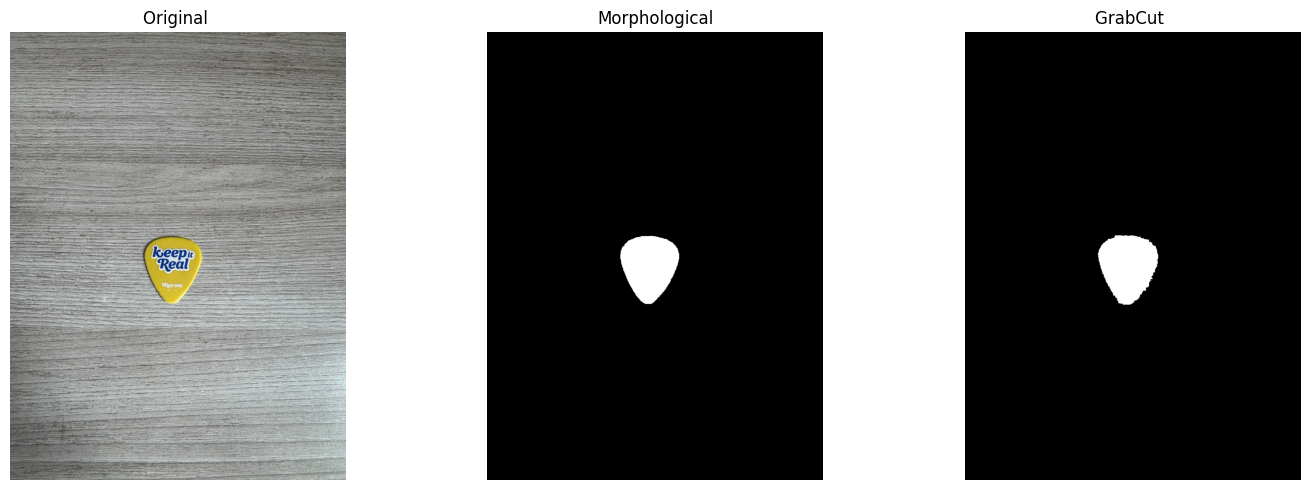

In [36]:
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title("Original ")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask_morph, cmap="gray")
plt.title("Morphological")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(mask_grabcut, cmap="gray")
plt.title("GrabCut ")
plt.axis("off")

plt.tight_layout()
plt.show()